In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, confusion_matrix,roc_curve, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Task 1: tabular supervised classification

Train a classification model using the public training data and generate predictions for the held-out feature rows.
Output contract:

    Input file: dataset/task1/test_features.csv
    Required output file: outputs/task1_predictions.csv
    Required columns: patient_id, prediction
    The output must contain exactly one row for every row in test_features.csv, with matching patient IDs and no missing values.
    The submitted solution must be your-sollution/task1_solution.py or your-sollution/task1_solution.ipynb.


In [42]:
df = pd.read_csv('/content/drive/MyDrive/рабочее/csv и материалы/train.csv')
df_test = pd.read_csv('/content/drive/MyDrive/рабочее/csv и материалы/test_features.csv')
df

,patient_id,Возраст,Пол_мужской,ИМТ,Окружность_талии_см,САД_мм_рт_ст,ДАД_мм_рт_ст,Пульсовое_давление,Глюкоза_натощак_ммоль_л,HbA1c_%,ЛПНП_ммоль_л,ЛПВП_ммоль_л,Триглицериды_ммоль_л,СКФ_мл_мин,Курение,Физическая_активность_мин_нед,prediction,Статус_глюкозы,Доклинический_риск
0,1,41,1,24.24,81.04,113.19,62.54,50.65,4.595,4.65,NaN,NaN,1.379,115.52,0,165.8,0,0,0
1,4,53,0,19.84,73.44,119.75,71.59,48.15,4.431,5.08,2.268,2.022,1.467,93.39,0,248.1,0,0,0
2,5,53,1,24.28,82.06,127.07,70.34,56.73,4.997,5.04,2.459,1.325,0.967,88.41,0,230.5,0,0,0
3,6,60,1,25.19,91.89,116.98,82.00,34.98,5.491,5.00,3.700,0.722,1.505,91.06,1,132.5,1,0,0
4,7,59,1,24.45,84.07,129.12,82.70,46.42,6.456,4.80,3.960,1.406,2.274,89.74,1,177.4,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,995,61,0,33.64,94.33,127.45,65.00,62.45,5.964,5.31,4.523,0.900,1.485,81.44,0,160.3,1,1,0
796,996,50,1,26.87,92.74,124.95,74.42,50.52,5.836,5.35,2.580,1.573,NaN,90.27,0,199.5,0,1,0
797,997,56,1,20.99,81.79,115.30,72.70,42.60,5.533,5.14,3.291,1.155,1.798,102.73,1,220.8,1,0,0
798,999,51,0,24.54,88.82,120.16,68.60,51.56,4.868,4.99,3.060,1.738,1.312,83.51,0,220.1,0,0,0


patient_id                        0
Возраст                           0
Пол_мужской                       0
ИМТ                               0
Окружность_талии_см               0
САД_мм_рт_ст                      0
ДАД_мм_рт_ст                      0
Пульсовое_давление                0
Глюкоза_натощак_ммоль_л           0
HbA1c_%                           0
ЛПНП_ммоль_л                     35
ЛПВП_ммоль_л                     45
Триглицериды_ммоль_л             46
СКФ_мл_мин                       47
Курение                           0
Физическая_активность_мин_нед     0
prediction                        0
Статус_глюкозы                    0
Доклинический_риск                0
dtype: int64
patient_id                        0
Возраст                           0
Пол_мужской                       0
ИМТ                               0
Окружность_талии_см               0
САД_мм_рт_ст                      0
ДАД_мм_рт_ст                      0
Пульсовое_давление                0
Глюкоза_натощак

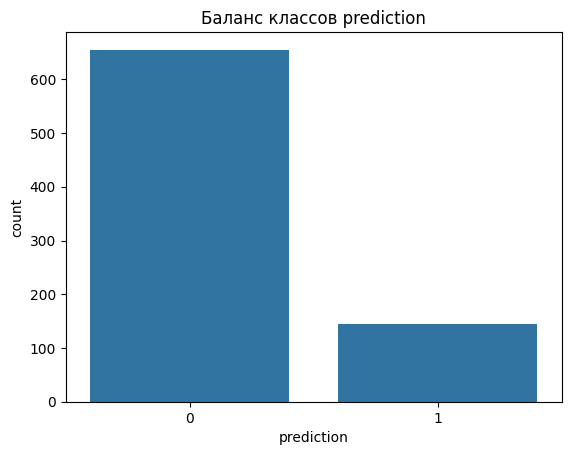

In [43]:
print(df.isna().sum())
print(df_test.isna().sum())
print(df['prediction'].value_counts(normalize=True))

sns.countplot(x='prediction', data=df)
plt.title('Баланс классов prediction')
plt.show()

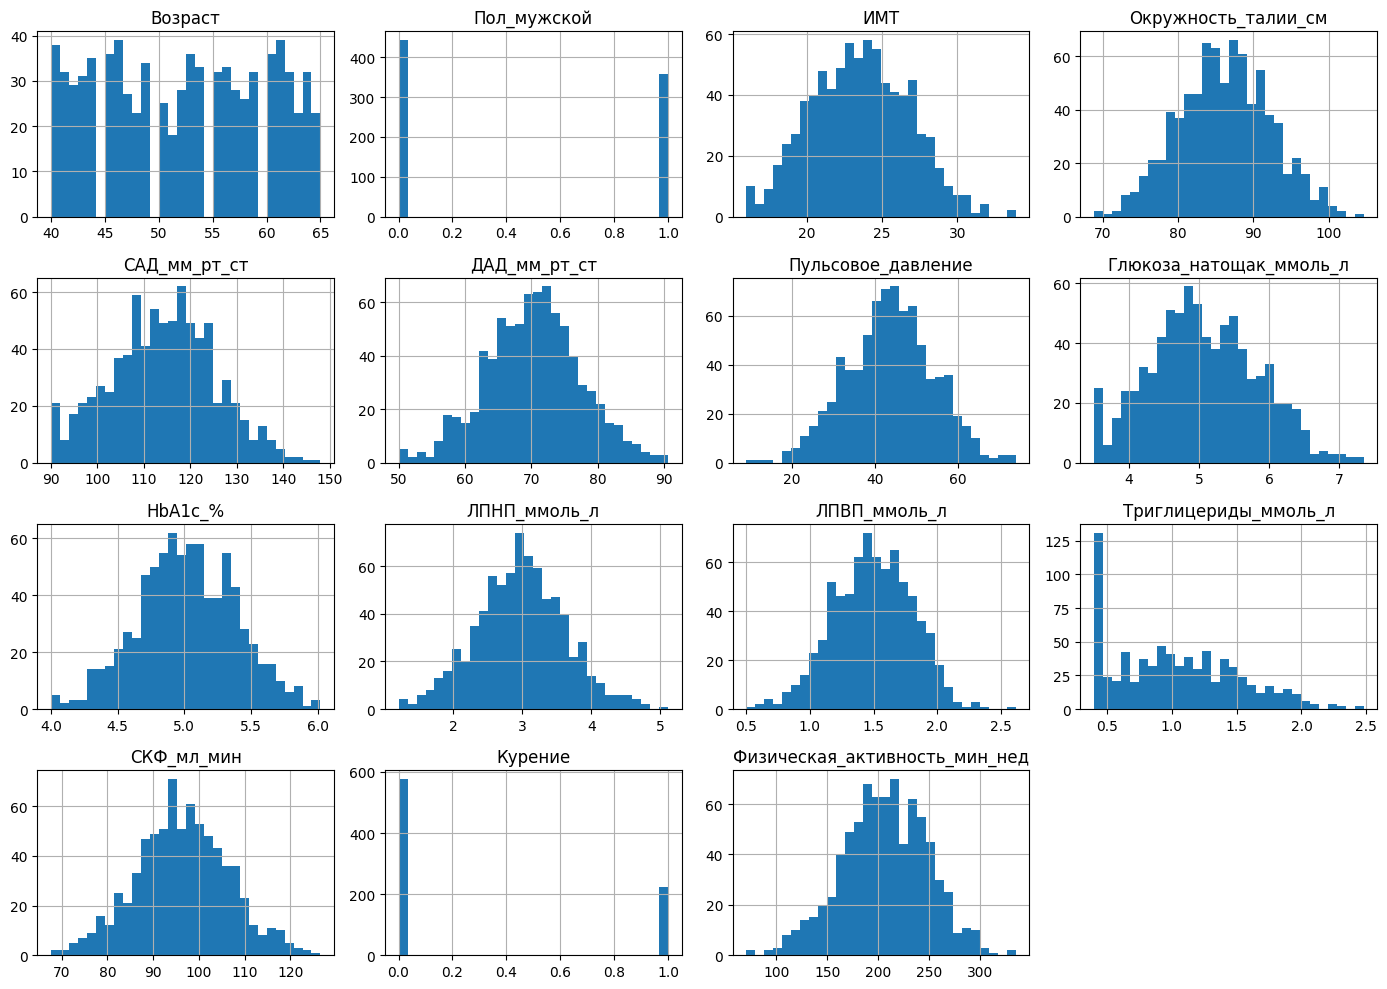

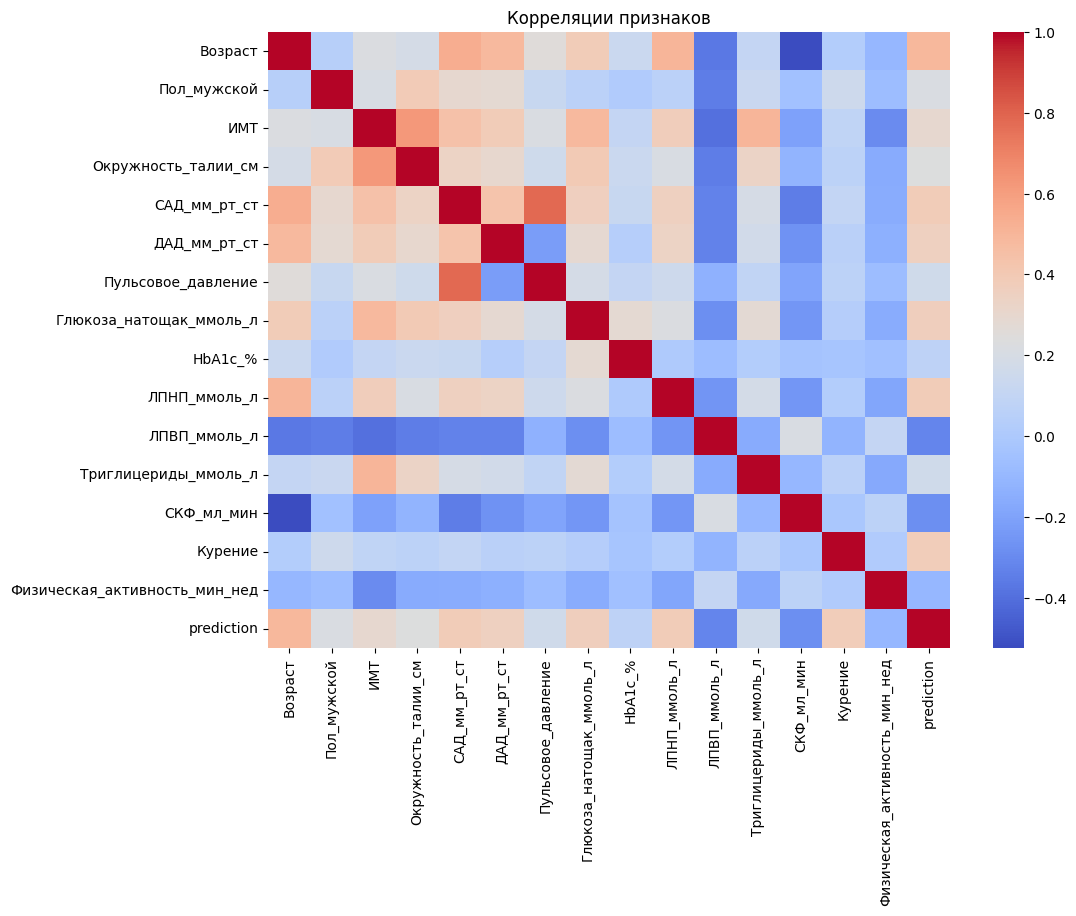

In [44]:
features = [c for c in df.columns if c not in ['patient_id', 'prediction', 'Статус_глюкозы', 'Доклинический_риск']]

df[features].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 8))
sns.heatmap(df[features + ['prediction']].corr(), annot=False, cmap='coolwarm')
plt.title('Корреляции признаков')
plt.show()

In [45]:
y_all = df['prediction'].values.astype(np.float32)

drop_cols = ['patient_id', 'prediction', 'Статус_глюкозы', 'Доклинический_риск']
X_all = df.drop(columns=drop_cols)
X_test_raw = df_test.drop(columns=['patient_id', 'Статус_глюкозы', 'Доклинический_риск'])
X_test_raw = X_test_raw[X_all.columns]

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
print(X_train.shape, X_val.shape, X_test_raw.shape)

(640, 15) (160, 15) (200, 15)


In [46]:
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_val= imputer.transform(X_val)
X_test = imputer.transform(X_test_raw)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

In [47]:
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train).reshape(-1, 1)
X_val_t = torch.tensor(X_val)
y_val_t = torch.tensor(y_val).reshape(-1, 1)

batch_size = 32

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t),batch_size=batch_size, shuffle=False)

In [48]:
class RiskFFN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RiskFFN(X_train.shape[1]).to(device)
print(device)

cpu


In [49]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f'pos_weight = {pos_weight.item():.3f}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.001)

pos_weight = 4.517


In [50]:
epochs = 100
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(val_loss)

    if (epoch + 1) % 20 == 0:
        print(f'epoch {epoch+1}/{epochs} - train loss: {train_loss:.4f} - val loss: {val_loss:.4f}')

epoch 20/100 - train loss: 0.2578 - val loss: 0.4132
epoch 40/100 - train loss: 0.1901 - val loss: 0.4564
epoch 60/100 - train loss: 0.1133 - val loss: 0.4952
epoch 80/100 - train loss: 0.0789 - val loss: 0.5470
epoch 100/100 - train loss: 0.0770 - val loss: 0.6433


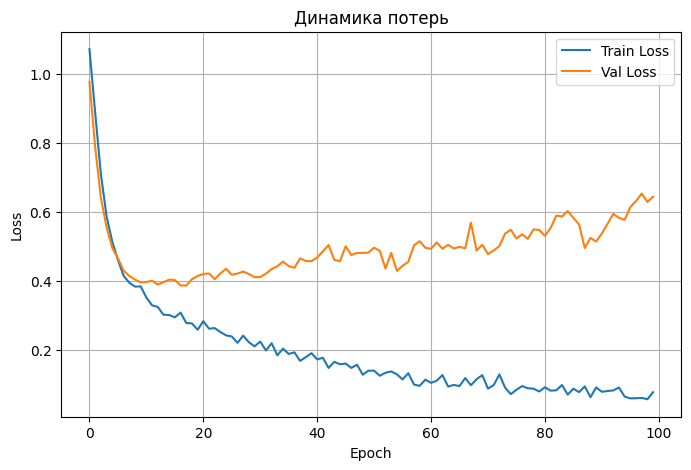

In [51]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Динамика потерь')
plt.legend()
plt.grid(True)
plt.show()

accuracy:0.9563
precision:0.8667
recall:0.8966
specificity0.9695
f1-score:0.8814
roc auc:0.9782

              precision    recall  f1-score   support

         0.0       0.98      0.97      0.97       131
         1.0       0.87      0.90      0.88        29

    accuracy                           0.96       160
   macro avg       0.92      0.93      0.93       160
weighted avg       0.96      0.96      0.96       160



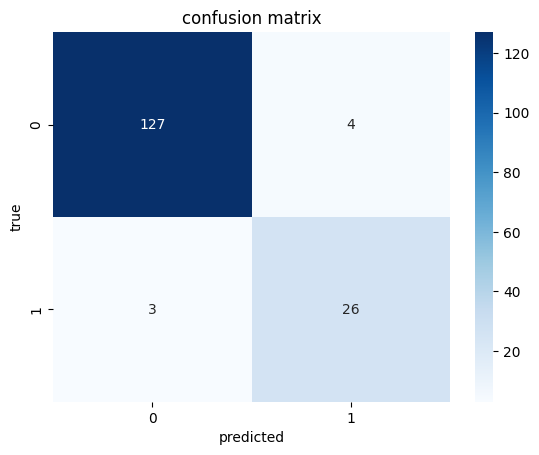

In [52]:
model.eval()
val_probs, val_true = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch= X_batch.to(device)
        logits=model(X_batch)
        probs=torch.sigmoid(logits)
        val_probs.extend(probs.cpu().numpy().flatten())
        val_true.extend(y_batch.numpy().flatten())

val_probs = np.array(val_probs)
val_true = np.array(val_true)
val_pred = (val_probs >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(val_true, val_pred).ravel()
specificity = tn / (tn + fp)

print(f'accuracy:{accuracy_score(val_true, val_pred):.4f}')
print(f'precision:{precision_score(val_true, val_pred):.4f}')
print(f'recall:{recall_score(val_true, val_pred):.4f}')
print(f'specificity{specificity:.4f}')
print(f'f1-score:{f1_score(val_true, val_pred):.4f}')
print(f'roc auc:{roc_auc_score(val_true, val_probs):.4f}')
print()
print(classification_report(val_true, val_pred))

sns.heatmap(confusion_matrix(val_true, val_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('predicted')
plt.ylabel('true')
plt.title('confusion matrix')
plt.show()

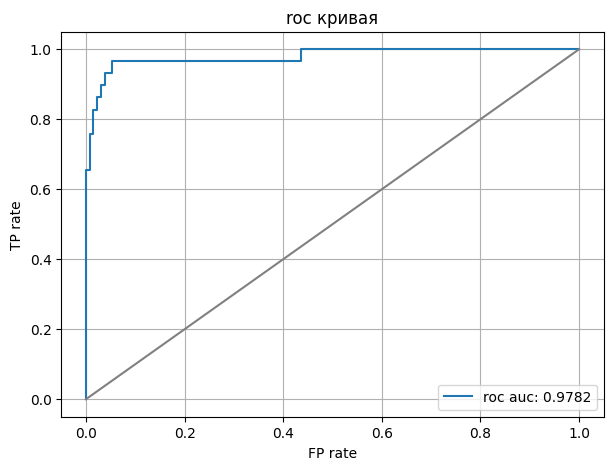

In [53]:
fpr, tpr, _ = roc_curve(val_true, val_probs)
auc=roc_auc_score(val_true, val_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'roc auc: {auc:.4f}')
plt.plot([0, 1], [0, 1], color='gray')
plt.xlabel('FP rate')
plt.ylabel('TP rate')
plt.title('roc кривая')
plt.legend()
plt.grid(True)
plt.show()

In [54]:
X_test_final = imputer.transform(df_test[X_all.columns])
X_test_final = scaler.transform(X_test_final)
X_test_final = X_test_final.astype(np.float32)
X_test_t = torch.tensor(X_test_final)

test_pred_prob = []

with torch.no_grad():
    for i in range(0, len(X_test_t), batch_size):
        X_batch = X_test_t[i:i+batch_size].to(device)
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)
        test_pred_prob.extend(probs.cpu().numpy().flatten())

test_pred_prob = np.array(test_pred_prob)
test_pred = (test_pred_prob >= 0.5).astype(int)

df_pred = pd.DataFrame({
    'patient_id': df_test['patient_id'].values,
    'prediction': test_pred
})

df_pred.to_csv('/content/drive/MyDrive/рабочее/csv и материалы/task1_predictions.csv', index=False)
df_pred

,patient_id,prediction
0,2,0
1,3,0
2,8,0
3,18,0
4,19,0
...,...,...
195,986,0
196,990,1
197,992,0
198,993,1


In [55]:
features_fuzzy = ['Глюкоза_натощак_ммоль_л', 'ИМТ', 'Окружность_талии_см',
                  'ЛПНП_ммоль_л', 'Триглицериды_ммоль_л']

df_target = df[
    (df['Глюкоза_натощак_ммоль_л'] >= 5.4) &
    (df['Глюкоза_натощак_ммоль_л'] <= 6.5)
].copy()

print(f'целевая группа: {len(df_target)} пациентов')

X_fuzzy = df_target[features_fuzzy].fillna(df_target[features_fuzzy].mean())
X_fuzzy_scaled = StandardScaler().fit_transform(X_fuzzy)
y_fuzzy = df_target['Статус_глюкозы'].values

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fuzzy_scaled, y_fuzzy, test_size=0.3, random_state=42, stratify=y_fuzzy
)


class SimpleFuzzyKNN:
    def __init__(self, k=7, m=2.0):
        self.k = k
        self.m = m

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y.astype(int)
        self.classes_ = np.unique(y)
        return self

    def predict_membership(self, X):
        memberships = np.zeros((X.shape[0], len(self.classes_)))
        for i in range(X.shape[0]):
            distances = np.sqrt(np.sum((X[i] - self.X_train) ** 2, axis=1))
            idx = np.argsort(distances)[:self.k]
            dists = np.maximum(distances[idx], 1e-10)
            weights = 1.0 / (dists ** self.m)
            for c in self.classes_:
                mask = self.y_train[idx] == c
                memberships[i, c] = np.sum(weights[mask])
            if np.sum(memberships[i]) > 0:
                memberships[i] /= np.sum(memberships[i])
        return memberships

    def predict_risk_score(self, X):
        memberships = self.predict_membership(X)
        risk_score = memberships[:, 1] * 0.5 + memberships[:, 2] * 1.0
        return risk_score, memberships


fuzzy_model = SimpleFuzzyKNN(k=7, m=2.0)
fuzzy_model.fit(X_train_f, y_train_f)
risk_scores, memberships = fuzzy_model.predict_risk_score(X_test_f)

print(f'средний риск: {np.mean(risk_scores):.3f}')

целевая группа: 247 пациентов
средний риск: 0.454


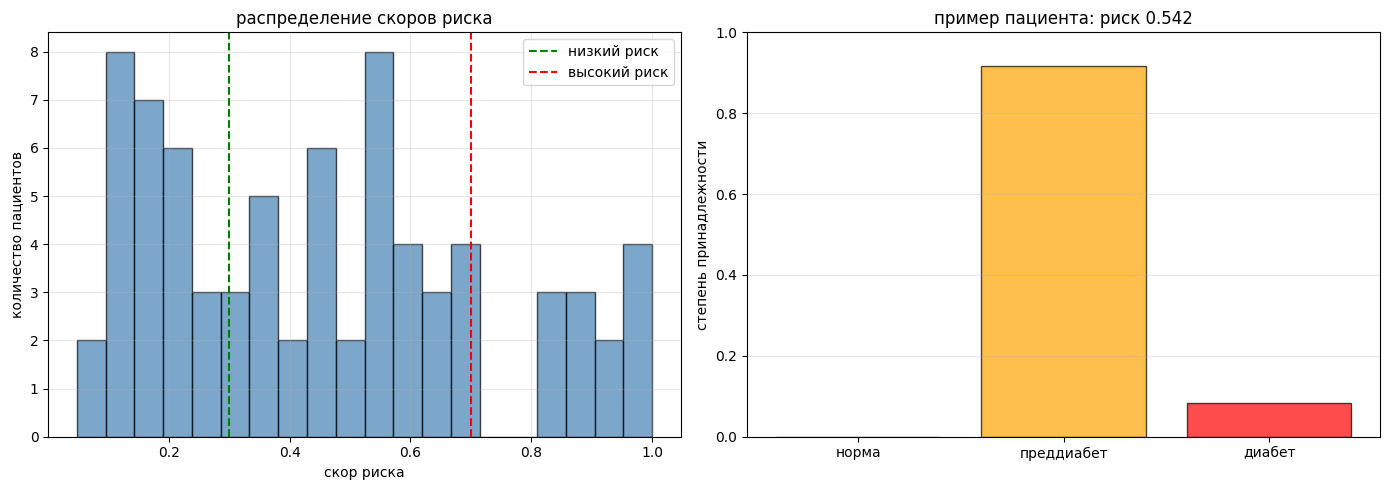

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(risk_scores, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.3, color='green', linestyle='--', label='низкий риск')
axes[0].axvline(x=0.7, color='red', linestyle='--', label='высокий риск')
axes[0].set_xlabel('скор риска')
axes[0].set_ylabel('количество пациентов')
axes[0].set_title('распределение скоров риска')
axes[0].legend()
axes[0].grid(alpha=0.3)

example_idx = 0
colors = ['green', 'orange', 'red']
axes[1].bar(['норма', 'преддиабет', 'диабет'],
            memberships[example_idx],
            color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('степень принадлежности')
axes[1].set_title(f'пример пациента: риск {risk_scores[example_idx]:.3f}')
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()